In [2]:
import os
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler



In [3]:
current_working_directory = os.getcwd()
home_dir = os.path.abspath(os.path.join(current_working_directory, os.pardir))
data_path = os.path.join(home_dir, 'data/')

In [11]:
func_connectome_input = pd.read_csv(os.path.join(data_path, 'TRAIN/TRAIN_FUNCTIONAL_CONNECTOME_MATRICES.csv'))
labels = pd.read_excel(os.path.join(data_path, 'TRAIN/TRAINING_SOLUTIONS.xlsx'))

In [12]:
input_merged_hd = pd.merge(func_connectome_input, labels, on='participant_id', how='inner')
# input_merged_hd = input_merged_hd.drop('participant_id', axis=1, inplace=True)


In [9]:
input_merged_hd 


,0throw_1thcolumn,0throw_2thcolumn,0throw_3thcolumn,0throw_4thcolumn,0throw_5thcolumn,0throw_6thcolumn,0throw_7thcolumn,0throw_8thcolumn,0throw_9thcolumn,0throw_10thcolumn,...,195throw_198thcolumn,195throw_199thcolumn,196throw_197thcolumn,196throw_198thcolumn,196throw_199thcolumn,197throw_198thcolumn,197throw_199thcolumn,198throw_199thcolumn,ADHD_Outcome,Sex_F
0,0.093473,0.146902,0.067893,0.015141,0.070221,0.063997,0.055382,-0.035335,0.068583,0.029271,...,-0.050968,-0.014365,0.128066,0.112646,-0.058980,0.028228,0.133582,0.143372,1,0
1,0.029580,0.179323,0.112933,0.038291,0.104899,0.064250,0.008488,0.077505,-0.004750,-0.035073,...,0.020891,0.017754,0.094040,0.035141,0.032537,0.075007,0.115350,0.138200,1,1
2,-0.051580,0.139734,0.068295,0.046991,0.111085,0.026978,0.151377,0.021198,0.083721,-0.014275,...,0.028773,0.024556,0.166343,0.058925,0.035485,0.063661,0.042862,0.162162,1,1
3,0.016273,0.204702,0.115980,0.043103,0.056431,0.057615,0.055773,0.075030,0.001033,-0.064031,...,0.018607,0.016193,0.072955,0.130135,0.056120,0.084784,0.114148,0.190584,1,1
4,0.065771,0.098714,0.097604,0.112988,0.071139,0.085607,0.019392,-0.036403,-0.020375,0.005426,...,-0.047530,-0.031443,0.221213,0.007343,0.005763,0.083820,0.079582,0.067269,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1208,0.022932,0.024830,-0.006514,0.021070,0.093365,0.083369,0.010991,0.035838,0.023909,-0.010682,...,-0.016413,0.089110,0.118587,-0.060868,0.124443,0.028510,0.113064,0.103809,0,1
1209,0.047078,0.135955,0.144366,0.054938,0.065760,0.113550,0.032621,0.025349,0.011848,-0.015673,...,-0.020920,0.030450,0.190241,0.026461,-0.011593,0.139483,-0.064480,0.070354,1,0
1210,0.094541,0.145280,0.061964,0.030562,0.078278,0.105857,0.043984,0.039145,0.032024,-0.018199,...,-0.038452,0.066608,0.143446,0.051221,0.127495,0.106242,-0.036065,0.151341,0,1
1211,-0.001533,0.128562,0.045000,-0.008742,0.003673,0.086494,0.090101,-0.037449,-0.026334,0.050006,...,-0.061617,-0.001699,0.106568,0.023427,-0.003520,0.174972,0.041198,0.152029,1,1


In [14]:
# Separating out the features
x = input_merged_hd.loc[:, (input_merged_hd.columns != 'ADHD_Outcome') & 
                  (input_merged_hd.columns != 'Sex_F') & 
                  (input_merged_hd.columns != 'participant_id')].values

# Separating out the target
y1 = input_merged_hd.loc[:,['ADHD_Outcome']].values
y2 = input_merged_hd.loc[:,['Sex_F']].values

In [15]:
# Standardize the features

x = StandardScaler().fit_transform(x)

In [21]:

pca_hd = PCA(n_components=2)
principalComponents_HD = pca_hd.fit_transform(x)

In [23]:
principalDf = pd.DataFrame(data = principalComponents_HD,
                           columns = ['c0','c1'])
                        #    columns = ['c0','c1','c2','c3','c4','c5','c6','c7','c8','c9'])
principalDf

,c0,c1
0,1.996910,1.950493
1,10.852228,9.182334
2,3.636517,11.478574
3,-3.608026,-10.594076
4,9.634388,1.715369
...,...,...
1208,5.091535,4.044963
1209,2.868556,5.636471
1210,4.559094,-6.351863
1211,-1.986512,-5.600387


In [24]:
finalDf = pd.concat([principalDf, input_merged_hd[['ADHD_Outcome','Sex_F']]], axis = 1)


In [26]:
finalDf.ADHD_Outcome.value_counts()


1    831
0    382
Name: ADHD_Outcome, dtype: int64

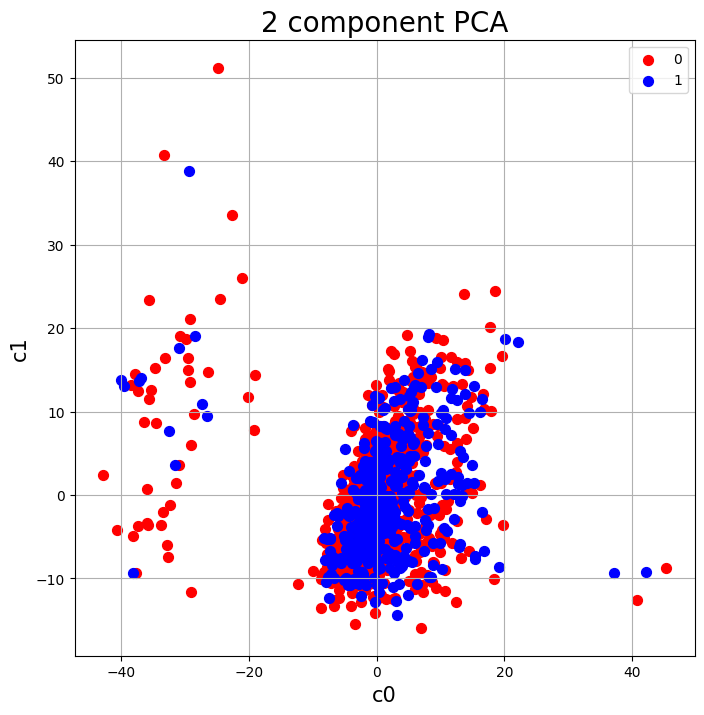

In [30]:
fig = plt.figure(figsize = (8,8))
ax = fig.add_subplot(1,1,1) 
ax.set_xlabel('c0', fontsize = 15)
ax.set_ylabel('c1', fontsize = 15)
ax.set_title('2 component PCA', fontsize = 20)

targets = [0, 1]
colors = ['r', 'b']
for target, color in zip(targets,colors):
    indicesToKeep = finalDf['Sex_F'] == target
    ax.scatter(finalDf.loc[indicesToKeep, 'c0']
               , finalDf.loc[indicesToKeep, 'c1']
               , c = color
               , s = 50)
ax.legend(targets)
ax.grid()